In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import time
import pickle
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.ticker as ticker

from f_compare_bn import * 
from f_recog_prior_norm_plot import plot_z_white_fig4_style

# global var
S0 = 1.0
K = 1.0
r = 0.03
sigma = np.sqrt(0.05)
T = 1.5
BS_eta = (S0, K, r, sigma, T)
# S0, K, r, kappa, theta, xi, rho, Y0, T = Hes_eta
Hes_eta = (S0, K, r, 2, 0.05, 0.5, -0.7, 0.05, T)

B = 0.8 # down-and-out must B < S0 and B < K
model_type = 'bs' # hes or bs
# barr_type = 'barr' # van or barr
# opt_type = 'call' # call or put
# chunk_dir = f"/mnt/d/bs_chunks_correction/" if model_type == 'bs' else f"/mnt/d/hes_chunks_correction/"
# eta_path = "/mnt/d/bs_eta_basic.h5" if model_type == 'bs' else "/mnt/d/hes_eta_basic.h5"

if not((B < S0) & (B < K)):
    raise ValueError("down-and-out : B should be smaller than S0 and K")

# if not(opt_type == 'call' or  opt_type == 'put'):
#     raise ValueError("option_type must be 'call' or 'put'")

# if not(barr_type == 'van' or  barr_type == 'barr'):
#     raise ValueError("barr_type must be 'van' or 'barr'")

if not(model_type == 'hes' or  model_type == 'bs'):
    raise ValueError("model_type must be 'hes' or 'bs'")

if not(torch.cuda.is_available()):
    raise ValueError("CUDA is not available")
device = torch.device("cuda")

bs_stats = {
    "x_mean": -0.1045446063,
    "x_std": 0.6455563393,
    "m_mean": -0.4579059199,
    "m_std": 0.5553496410
}

# if model_type == 'hes':
#     if barr_type == 'barr':
#         if opt_type == 'call':
#             bench_price = 0.115733
#         else: # put
#             bench_price = 0.005170
#     else: # van
#         if opt_type == 'call':
#             bench_price = 0.124491
#         else: # put
#             bench_price = 0.080488

# elif model_type == 'bs':
#     if barr_type == 'barr':
#         if opt_type == 'call':
#             bench_price = 0.123493
#         else: # put
#             bench_price = 0.009535
#     else: # van
#         if opt_type == 'call':
#             bench_price = 0.129944
#         else: # put
#             bench_price = 0.085942

In [43]:
# CVAE training settings
dim_z       = 2 # 8, 12
hidden_dims = [128, 128, 64] # [128, 128, 64], [256, 256, 128], [512, 512, 256]
batch_size  = 4096 # 1024, 2048, 4096, 8192
bn_chunks   = None # None or num
use_bn      = True if bn_chunks is not None else False
lr          = 1e-4 # 1e-3, 1e-4, 1e-5, 1e-6
l1          = 2
lr2         = 1e-6
l2          = 3
num_chunks  = 485
beta        = 1
warmup_chunks = None # None or num
validation_chunk_idxs = [15,24,78]
#val_every_chunks = 1
resume_path = None # or None 이어서 학습하고 싶을 때
save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
# save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
# result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"


n_samples = 10000 # n_samples= 1k, 10k, 100k
if n_samples % 2 != 0:
    raise ValueError("n_samples should be an even number for antithetic sampling")

if model_type == 'hes':
    test_etas = [0.03, 2.0,  0.05, 0.5, -0.7, 0.05, 1.5]
    eta_keys  = ['r', 'lambda', 'v_bar', 'xi', 'rho', 'Y0', 'T']
else: # model_type = 'bs'
    test_etas = [r, sigma, T]
    eta_keys  = ['r', 'sigma', 'T']

# Loss history

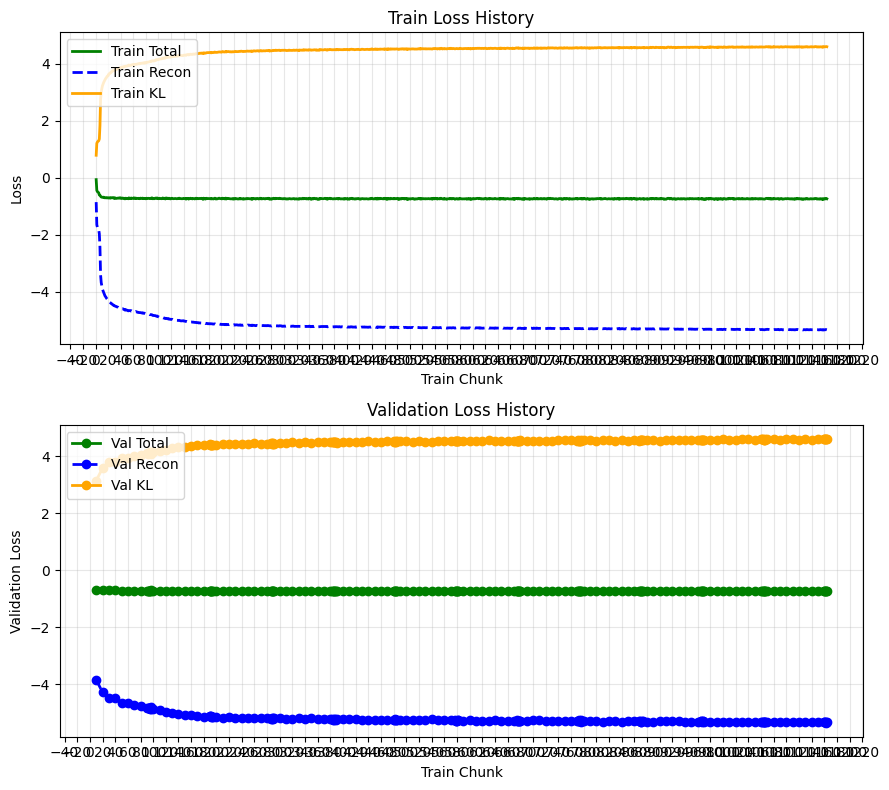

In [122]:
ckpt = torch.load(save_path, map_location=device, weights_only=False)
chunk_loss_history = ckpt.get("chunk_loss_history", None)

if chunk_loss_history is None:
    raise ValueError("checkpoint에 chunk_loss_history가 없습니다.")

train_chunks = np.arange(1, len(chunk_loss_history["total_loss"]) + 1)
val_chunks = np.asarray(chunk_loss_history.get("val_global_chunk", []), dtype=int)
has_val = len(val_chunks) > 0

n_rows = 2 if has_val else 1
fig, axes = plt.subplots(n_rows, 1, figsize=(9, 4 * n_rows), sharex=False)
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

# train loss history
ax = axes[0]
ax.plot(train_chunks, chunk_loss_history["total_loss"], label="Train Total", color="green", linewidth=2)
ax.plot(train_chunks, chunk_loss_history["recon_loss"], label="Train Recon", color="blue", linestyle="--", linewidth=2)
ax.plot(train_chunks, chunk_loss_history["KL_loss"], label="Train KL", color="orange", linewidth=2)
ax.set_xlabel("Train Chunk")
ax.set_ylabel("Loss")
ax.set_title("Train Loss History")
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.legend()
ax.grid(True, alpha=0.3)

# validation loss history
if has_val:
    ax = axes[1]
    ax.plot(val_chunks, chunk_loss_history["val_total_loss"], marker="o", label="Val Total", color="green", linewidth=2)
    ax.plot(val_chunks, chunk_loss_history["val_recon_loss"], marker="o", label="Val Recon", color="blue", linestyle="--", linewidth=2)
    ax.plot(val_chunks, chunk_loss_history["val_KL_loss"], marker="o", label="Val KL", color="orange", linewidth=2)
    ax.set_xlabel("Train Chunk")
    ax.set_ylabel("Validation Loss")
    ax.set_title("Validation Loss History")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    print("validation loss history가 없습니다. validation_chunk_idxs를 넣고 학습한 checkpoint인지 확인하세요.")

plt.tight_layout()
plt.show()


In [42]:
# loss history
ckpt = torch.load(save_path, map_location=device, weights_only=False)
chunk_loss_history = ckpt.get("chunk_loss_history", None)
chunk_indices = ckpt["chunk_loss_history"]["chunk_idx"]

for i in range(len(chunk_loss_history["total_loss"])):
    print(f"Num : {chunk_loss_history['global_chunk'][i]}, Idx : {chunk_indices[i]}, Total Loss: {chunk_loss_history['total_loss'][i]:.4f}, Recon Loss: {chunk_loss_history['recon_loss'][i]:.4f}, KL Loss: {chunk_loss_history['KL_loss'][i]:.4f}")

Num : 0, Idx : 88, Total Loss: -0.0679, Recon Loss: -0.8565, KL Loss: 0.7886
Num : 1, Idx : 8, Total Loss: -0.4461, Recon Loss: -1.6535, KL Loss: 1.2074
Num : 2, Idx : 75, Total Loss: -0.4899, Recon Loss: -1.7450, KL Loss: 1.2551
Num : 3, Idx : 41, Total Loss: -0.5118, Recon Loss: -1.7903, KL Loss: 1.2785
Num : 4, Idx : 17, Total Loss: -0.5291, Recon Loss: -1.8241, KL Loss: 1.2950
Num : 5, Idx : 66, Total Loss: -0.6062, Recon Loss: -1.9671, KL Loss: 1.3610
Num : 6, Idx : 57, Total Loss: -0.6155, Recon Loss: -2.4447, KL Loss: 1.8292
Num : 7, Idx : 31, Total Loss: -0.6500, Recon Loss: -3.4083, KL Loss: 2.7583
Num : 8, Idx : 58, Total Loss: -0.6763, Recon Loss: -3.6796, KL Loss: 3.0033
Num : 9, Idx : 87, Total Loss: -0.6819, Recon Loss: -3.8112, KL Loss: 3.1293
Num : 10, Idx : 45, Total Loss: -0.6892, Recon Loss: -3.9195, KL Loss: 3.2302
Num : 11, Idx : 65, Total Loss: -0.6867, Recon Loss: -3.9767, KL Loss: 3.2900
Num : 12, Idx : 97, Total Loss: -0.6832, Recon Loss: -4.0312, KL Loss: 3.34

In [73]:
# validation dim-z KL mean value
ckpt = torch.load(save_path, map_location=device, weights_only=False)
chunk_loss_history = ckpt.get("chunk_loss_history", None)

if chunk_loss_history is None:
    raise ValueError("checkpoint에 chunk_loss_history가 없습니다.")

val_chunks = chunk_loss_history.get("val_global_chunk", [])
val_kl_dim_mean = chunk_loss_history.get("val_kl_dim_mean", [])

if len(val_chunks) == 0 or len(val_kl_dim_mean) == 0:
    raise ValueError("validation KL dim 기록이 없습니다. validation_chunk_idxs를 넣고 학습한 checkpoint인지 확인하세요.")

for i in range(len(val_chunks)):
    kl_by_dim = val_kl_dim_mean[i]
    kl_text = " | ".join([f"z{j}: {v:.6f}" for j, v in enumerate(kl_by_dim)])
    print(f"Num : {val_chunks[i]}, {kl_text}")


Num : 10, z0: 0.000227 | z1: 2.195515 | z2: 0.000150 | z3: 0.000473 | z4: 0.000409 | z5: 0.000134 | z6: 0.832493 | z7: 0.000129
Num : 20, z0: 0.000039 | z1: 2.455833 | z2: 0.000027 | z3: 0.000135 | z4: 0.000170 | z5: 0.000030 | z6: 1.117510 | z7: 0.000039
Num : 30, z0: 0.000017 | z1: 2.561758 | z2: 0.000024 | z3: 0.000087 | z4: 0.000035 | z5: 0.000012 | z6: 1.208241 | z7: 0.000012
Num : 40, z0: 0.000003 | z1: 2.596237 | z2: 0.000003 | z3: 0.000018 | z4: 0.000014 | z5: 0.000004 | z6: 1.255595 | z7: 0.000006
Num : 50, z0: 0.000002 | z1: 2.630519 | z2: 0.000002 | z3: 0.000010 | z4: 0.000007 | z5: 0.000003 | z6: 1.291070 | z7: 0.000002
Num : 60, z0: 0.000002 | z1: 2.647417 | z2: 0.000002 | z3: 0.000007 | z4: 0.000005 | z5: 0.000002 | z6: 1.309866 | z7: 0.000003
Num : 70, z0: 0.000035 | z1: 2.667085 | z2: 0.000004 | z3: 0.000068 | z4: 0.000005 | z5: 0.000003 | z6: 1.327587 | z7: 0.000014
Num : 80, z0: 0.000002 | z1: 2.689823 | z2: 0.000002 | z3: 0.000004 | z4: 0.000004 | z5: 0.000009 | z6: 

# inference result

In [33]:
ckpt = torch.load(save_path, map_location=device, weights_only=False)

cvae = CVAE(
    dim_x=ckpt["dim_x"],
    dim_eta=ckpt["dim_eta"],
    dim_z=ckpt["dim_z"],
    hidden_dims=ckpt["hidden_dims"],
    use_bn=ckpt.get("use_bn", False),
).to(device)

state_dict = ckpt["model_state"]
if any(k.startswith("module.") for k in state_dict):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

cvae.load_state_dict(state_dict)
cvae.eval()

eta_raw = np.array(test_etas, dtype=np.float32)
eta_scaled = (eta_raw - ckpt["eta_min"]) / (ckpt["eta_max"] - ckpt["eta_min"] + 1e-8)
eta_t = torch.tensor(eta_scaled, dtype=torch.float32, device=device)

option_keys = ["van_call", "van_put", "barr_call", "barr_put"]
n_list = [1000, 10000, 100000]
n_repeats = 50
results_by_option = {key: {n: [] for n in n_list} for key in option_keys}


# 시간 측정용
# for n in n_list:
#     call_time = {n: [] for n in n_list}
#     put_time = {n: [] for n in n_list}
#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_vanilla(eta_t, K, r, T, "call", n)
#         torch.cuda.synchronize()
#         call_time[n].append(time.perf_counter()-start)

#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_vanilla(eta_t, K, r, T, "put", n)
#         torch.cuda.synchronize()
#         put_time[n].append(time.perf_counter()-start)
    
#     print(f"van call {n} mean time : {np.mean(call_time[n]):.6f}")
#     print(f"van put {n} mean time : {np.mean(put_time[n]):.6f}")


# for n in n_list:
#     call_time = {n: [] for n in n_list}
#     put_time = {n: [] for n in n_list}
#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_barrier(eta_t, B, K, r, T, "call", n)
#         torch.cuda.synchronize()
#         call_time[n].append(time.perf_counter()-start)

#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_barrier(eta_t, B, K, r, T, "put", n)
#         torch.cuda.synchronize()
#         put_time[n].append(time.perf_counter()-start)
    
#     print(f"barr call {n} mean time : {np.mean(call_time[n]):.6f}")
#     print(f"barr put {n} mean time : {np.mean(put_time[n]):.6f}")


# 결과 확인용
for n in n_list:
    for _ in range(n_repeats):
        prices = cvae.total_pricing(eta_t, B, K, r, T, n)
        for key in option_keys:
            results_by_option[key][n].append(prices[key])

for key in option_keys:
    cvae_result_path = f"{result_base_path}_{key}.pkl"
    with open(cvae_result_path, "wb") as f:
        pickle.dump(results_by_option[key], f)
    print(f"saved: {cvae_result_path}")

saved: result/cvae/bs/cvae_bs_2_128_4096_None_0.0001_1_[15, 24, 78]_chunk1358_van_call.pkl
saved: result/cvae/bs/cvae_bs_2_128_4096_None_0.0001_1_[15, 24, 78]_chunk1358_van_put.pkl
saved: result/cvae/bs/cvae_bs_2_128_4096_None_0.0001_1_[15, 24, 78]_chunk1358_barr_call.pkl
saved: result/cvae/bs/cvae_bs_2_128_4096_None_0.0001_1_[15, 24, 78]_chunk1358_barr_put.pkl


Vanilla Call
n=  1000 | mean=0.13132720 | 95% CI=±0.01255502 | error=+1.06%
n= 10000 | mean=0.13140880 | 95% CI=±0.00438479 | error=+1.13%
n=100000 | mean=0.13124588 | 95% CI=±0.00121444 | error=+1.00%

Vanilla Put
n=  1000 | mean=0.08525509 | 95% CI=±0.00560623 | error=-0.80%
n= 10000 | mean=0.08562265 | 95% CI=±0.00226015 | error=-0.37%
n=100000 | mean=0.08572299 | 95% CI=±0.00076637 | error=-0.25%

Barrier Call
n=  1000 | mean=0.12536307 | 95% CI=±0.01268085 | error=+1.51%
n= 10000 | mean=0.12538063 | 95% CI=±0.00453372 | error=+1.53%
n=100000 | mean=0.12517840 | 95% CI=±0.00126996 | error=+1.36%

Barrier Put
n=  1000 | mean=0.00980244 | 95% CI=±0.00195524 | error=+2.80%
n= 10000 | mean=0.00990655 | 95% CI=±0.00058971 | error=+3.90%
n=100000 | mean=0.00987797 | 95% CI=±0.00018596 | error=+3.60%



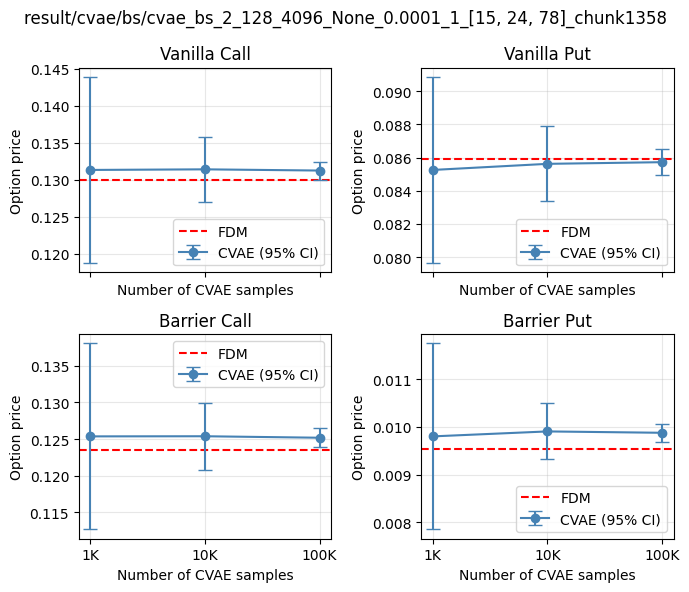

In [34]:
# CVAE inference result graphs for four option payoffs
n_list = [1000, 10000, 100000]
option_keys = ["van_call", "van_put", "barr_call", "barr_put"]
option_labels = {
    "van_call": "Vanilla Call",
    "van_put": "Vanilla Put",
    "barr_call": "Barrier Call",
    "barr_put": "Barrier Put",
}
bench_prices = {
    "hes": {
        "van_call": 0.124491,
        "van_put": 0.080488,
        "barr_call": 0.115733,
        "barr_put": 0.005170,
    },
    "bs": {
        "van_call": 0.129944,
        "van_put": 0.085942,
        "barr_call": 0.123493,
        "barr_put": 0.009535,
    },
}
# result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"

fig, axes = plt.subplots(2, 2, figsize=(7, 6), sharex=True)
axes = axes.ravel()

for ax, key in zip(axes, option_keys):
    with open(f"{result_base_path}_{key}.pkl", "rb") as f:
        results = pickle.load(f)

    means = np.array([np.mean(results[n]) for n in n_list])
    stds = np.array([np.std(results[n]) for n in n_list])
    ci = 1.96 * stds
    bench = bench_prices[model_type][key]

    print(option_labels[key])
    for n, mean, err in zip(n_list, means, ci):
        rel_err = (mean - bench) / (bench + 1e-12) * 100
        print(f"n={n:6d} | mean={mean:.8f} | 95% CI=±{err:.8f} | error={rel_err:+.2f}%")
    print()

    ax.axhline(bench, color="red", linestyle='--', linewidth=1.5, label="FDM")
    ax.errorbar(
        range(len(n_list)), means,
        yerr=ci, fmt="o-", color="steelblue", capsize=5, label="CVAE (95% CI)",
    )
    ax.set_xticks(range(len(n_list)))
    ax.set_xticklabels(["1K", "10K", "100K"])
    ax.set_title(option_labels[key])
    ax.set_xlabel("Number of CVAE samples")
    ax.set_ylabel("Option price")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(result_base_path)
plt.tight_layout()
plt.show()


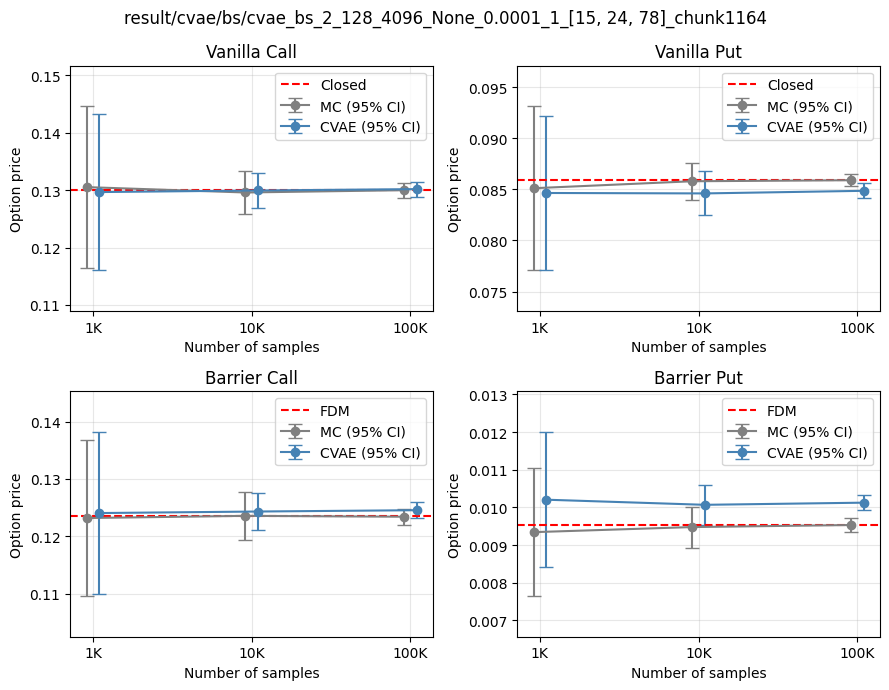

In [25]:
# 공용 그래프
n_list    = [1000, 10000, 100000]
option_keys = ["van_call", "van_put", "barr_call", "barr_put"]
option_labels = {
    "van_call": "Vanilla Call",
    "van_put": "Vanilla Put",
    "barr_call": "Barrier Call",
    "barr_put": "Barrier Put",
}
bench_prices = {
    "hes": {
        "van_call": 0.124491,
        "van_put": 0.080488,
        "barr_call": 0.115733,
        "barr_put": 0.005170,
    },
    "bs": {
        "van_call": 0.129944,
        "van_put": 0.085942,
        "barr_call": 0.123493,
        "barr_put": 0.009535,
    },
}

    
cvae_result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True)
axes = axes.ravel()

y_axis_pad_ratio = 0.25
x_axis_offset = 0.04
x_positions = np.arange(len(n_list))

for ax, key in zip(axes, option_keys):
    with open(f"{cvae_result_base_path}_{key}.pkl", "rb") as f:
        cvae_results = pickle.load(f)
    with open(f'result/mc/mc_{model_type}_{key}_results.pkl', 'rb') as f:
        mc_results = pickle.load(f)

    cvae_means = np.array([np.mean(cvae_results[n]) for n in n_list])
    cvae_stds = np.array([np.std(cvae_results[n]) for n in n_list])
    mc_means = np.array([np.mean(mc_results[n]) for n in n_list])
    mc_stds = np.array([np.std(mc_results[n]) for n in n_list])
    cvae_ci = 1.96 * cvae_stds
    mc_ci = 1.96 * mc_stds

    bench = bench_prices[model_type][key]

    y_values = np.concatenate([
        mc_means - mc_ci,
        mc_means + mc_ci,
        cvae_means - cvae_ci,
        cvae_means + cvae_ci,
    ])
    y_min = float(np.nanmin(y_values))
    y_max = float(np.nanmax(y_values))
    y_pad = (y_max - y_min) * y_axis_pad_ratio

    ax.errorbar(
        x_positions - x_axis_offset, mc_means, yerr=mc_ci,
        fmt='o-', color='grey', capsize=5, label=f'MC (95% CI)'
    )
    ax.errorbar(
        x_positions + x_axis_offset, cvae_means, yerr=cvae_ci, 
        fmt="o-", color="steelblue", capsize=5, label="CVAE (95% CI)",
    )

    bench_label = "Closed" if key.startswith("van") else "FDM"
    ax.axhline(bench, color="r", linestyle='--', linewidth=1.5, label=bench_label)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(["1K", "10K", "100K"])
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_title(option_labels[key])
    ax.set_xlabel("Number of samples")
    ax.set_ylabel("Option price")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(cvae_result_base_path)
plt.tight_layout()
plt.show()
